# Summary

The four proposed models were tested, then promising models were further developed based information gathered in Task 1.


In [1]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE_PATH = "/Users/maxswegmark/Desktop/project_financial_timeseries/data/spiff_data-2_interpolerad.csv"
DAY_COLUMN = "day_original"
RISK_FREE_RATE = 0.03
TRADING_DAYS = 252
HOLDOUT_SIZE = 1000

SHORT_WINDOWS = [5, 10, 20, 30, 50]
LONG_WINDOWS = [50, 100, 150, 200]
VOL_WINDOWS = [10, 20, 50, 100]
CORR_WINDOWS = [10, 20, 50, 100]
BREAKOUT_LOOKBACKS = [20, 50, 100, 150]
DIP_LONG_MA_WINDOWS = [100, 150, 200]
DIP_LOOKBACKS = [3, 5, 10]
GLOBAL_VOL_WINDOWS = [20, 50]
VOL_THRESHOLD_MULTIPLIERS = [1.0, 1.1, 1.25]

def load_data(file_path, day_column):
    df = pd.read_csv(file_path).copy()
    asset_columns = [col for col in df.columns if col.endswith("_interpolated")]

    if not asset_columns:
        raise ValueError("Inga '*_interpolated'-kolumner hittades i filen.")

    df = df[[day_column] + asset_columns].copy()
    df = df.dropna().sort_values(day_column).reset_index(drop=True)
    return df, asset_columns

def compute_returns(df, asset_columns):
    return df[asset_columns].pct_change()

def evaluate_strategy(portfolio_returns, risk_free_rate=0.03, trading_days=252):
    strategy_returns = portfolio_returns.dropna()

    if len(strategy_returns) == 0:
        return {
            "Observations": 0,
            "Cumulative Return": np.nan,
            "Annualized Return": np.nan,
            "Annualized Volatility": np.nan,
            "Sharpe Ratio": np.nan,
            "Max Drawdown": np.nan,
        }

    cumulative_return = (1 + strategy_returns).prod() - 1
    annualized_return = (1 + cumulative_return) ** (trading_days / len(strategy_returns)) - 1
    annualized_volatility = strategy_returns.std() * np.sqrt(trading_days)

    daily_rf = (1 + risk_free_rate) ** (1 / trading_days) - 1
    excess_returns = strategy_returns - daily_rf
    sharpe_ratio = np.nan

    if strategy_returns.std() > 0:
        sharpe_ratio = (excess_returns.mean() / strategy_returns.std()) * np.sqrt(trading_days)

    wealth_index = (1 + strategy_returns).cumprod()
    running_max = wealth_index.cummax()
    drawdown = (wealth_index - running_max) / running_max
    max_drawdown = drawdown.min()

    return {
        "Observations": len(strategy_returns),
        "Cumulative Return": cumulative_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown": max_drawdown,
    }

def weights_to_result(df, asset_columns, day_column, weights):
    asset_returns = compute_returns(df, asset_columns)
    portfolio_returns = (weights * asset_returns).sum(axis=1)

    result = df[[day_column]].copy()
    result["portfolio_return"] = portfolio_returns
    result["equity_curve"] = (1 + result["portfolio_return"].fillna(0)).cumprod()
    return result

def buy_and_hold_weights(df, asset_columns):
    n_assets = len(asset_columns)
    return pd.DataFrame(
        np.full((len(df), n_assets), 1 / n_assets),
        index=df.index,
        columns=asset_columns
    )

def ma_crossover_weights(df, asset_columns, short_window, long_window):
    prices = df[asset_columns].copy()
    ma_short = prices.rolling(short_window).mean()
    ma_long = prices.rolling(long_window).mean()
    signals = (ma_short > ma_long).astype(float)
    positions = signals.shift(1).fillna(0)
    active_counts = positions.sum(axis=1)
    return positions.div(active_counts.replace(0, np.nan), axis=0).fillna(0)

def volatility_scaled_ma_weights(df, asset_columns, short_window, long_window, vol_window):
    prices = df[asset_columns].copy()
    asset_returns = prices.pct_change()
    ma_short = prices.rolling(short_window).mean()
    ma_long = prices.rolling(long_window).mean()
    signals = (ma_short > ma_long).astype(float)
    positions = signals.shift(1).fillna(0)
    rolling_vol = asset_returns.rolling(vol_window).std()
    inv_vol = 1 / rolling_vol.replace(0, np.nan)
    raw_weights = positions * inv_vol
    weight_sums = raw_weights.sum(axis=1)
    return raw_weights.div(weight_sums.replace(0, np.nan), axis=0).fillna(0)

def corr_penalized_vol_ma_weights(df, asset_columns, short_window, long_window, vol_window, corr_window):
    prices = df[asset_columns].copy()
    asset_returns = prices.pct_change()
    ma_short = prices.rolling(short_window).mean()
    ma_long = prices.rolling(long_window).mean()
    signals = (ma_short > ma_long).astype(float)
    positions = signals.shift(1).fillna(0)

    rolling_vol = asset_returns.rolling(vol_window).std()
    inv_vol = 1 / rolling_vol.replace(0, np.nan)
    avg_corr = pd.DataFrame(index=df.index, columns=asset_columns, dtype=float)

    for i in range(corr_window - 1, len(df)):
        window_returns = asset_returns.iloc[i - corr_window + 1:i + 1]
        corr_matrix = window_returns.corr()
        for col in asset_columns:
            other_corrs = corr_matrix.loc[col].drop(labels=col, errors="ignore").dropna()
            avg_corr.loc[df.index[i], col] = other_corrs.mean() if len(other_corrs) > 0 else np.nan

    corr_penalty = 1 / (1 + avg_corr.clip(lower=0))
    raw_weights = positions * inv_vol * corr_penalty
    weight_sums = raw_weights.sum(axis=1)
    return raw_weights.div(weight_sums.replace(0, np.nan), axis=0).fillna(0)

def channel_breakout_weights(df, asset_columns, lookback):
    prices = df[asset_columns].copy()
    rolling_high = prices.shift(1).rolling(lookback).max()
    signals = (prices > rolling_high).astype(float)
    positions = signals.shift(1).fillna(0)
    active_counts = positions.sum(axis=1)
    return positions.div(active_counts.replace(0, np.nan), axis=0).fillna(0)

def basic_buy_dips_weights(df, asset_columns, long_ma_window, dip_lookback):
    prices = df[asset_columns].copy()
    long_ma = prices.rolling(long_ma_window).mean()
    trend_filter = prices > long_ma
    dip_return = prices.pct_change(dip_lookback)
    dip_signal = dip_return < 0
    signals = (trend_filter & dip_signal).astype(float)
    positions = signals.shift(1).fillna(0)
    active_counts = positions.sum(axis=1)
    return positions.div(active_counts.replace(0, np.nan), axis=0).fillna(0)

def buy_dips_global_vol_weights(df, asset_columns, long_ma_window, dip_lookback, global_vol_window, vol_threshold_multiplier):
    prices = df[asset_columns].copy()
    asset_returns = prices.pct_change()
    long_ma = prices.rolling(long_ma_window).mean()
    trend_filter = prices > long_ma
    dip_return = prices.pct_change(dip_lookback)
    dip_signal = dip_return < 0

    rolling_vol = asset_returns.rolling(global_vol_window).std()
    global_vol = rolling_vol.mean(axis=1)
    global_vol_baseline = global_vol.rolling(global_vol_window).median()
    allowed_regime = global_vol <= (vol_threshold_multiplier * global_vol_baseline)
    allowed_regime_df = pd.DataFrame({col: allowed_regime for col in asset_columns}, index=df.index)

    signals = (trend_filter & dip_signal & allowed_regime_df).astype(float)
    positions = signals.shift(1).fillna(0)
    active_counts = positions.sum(axis=1)
    return positions.div(active_counts.replace(0, np.nan), axis=0).fillna(0)

def param_grid_to_list(grid):
    if not grid:
        return [{}]
    keys = list(grid.keys())
    values = [grid[key] for key in keys]
    return [dict(zip(keys, combo)) for combo in itertools.product(*values)]

def evaluate_model_configs(df, asset_columns, day_column, model_name, weight_builder, grid, sample_label):
    rows = []
    for params in param_grid_to_list(grid):
        weights = weight_builder(df, asset_columns, params)
        result = weights_to_result(df, asset_columns, day_column, weights)
        metrics = evaluate_strategy(result["portfolio_return"], RISK_FREE_RATE, TRADING_DAYS)
        rows.append({
            "Model": model_name,
            "Sample": sample_label,
            **params,
            **metrics,
        })
    result_df = pd.DataFrame(rows)
    if {"short_window", "long_window"}.issubset(result_df.columns):
        result_df = result_df[result_df["short_window"] < result_df["long_window"]].copy()
    return result_df.sort_values("Sharpe Ratio", ascending=False).reset_index(drop=True)

def split_backtest(df_train, df_test, asset_columns, day_column, weight_builder, params):
    train_weights = weight_builder(df_train, asset_columns, params)
    train_result = weights_to_result(df_train, asset_columns, day_column, train_weights)

    combined_df = pd.concat([df_train, df_test], ignore_index=True)
    combined_weights = weight_builder(combined_df, asset_columns, params)
    combined_result = weights_to_result(combined_df, asset_columns, day_column, combined_weights)
    test_result = combined_result.iloc[len(df_train):].copy().reset_index(drop=True)
    return train_result, test_result

def show_model_results(model_name, train_eval, best_params, train_result, test_result):
    test_metrics = evaluate_strategy(test_result["portfolio_return"], RISK_FREE_RATE, TRADING_DAYS)

    print(f"===== {model_name} =====")
    print("Chosen parameters from training:")
    print(best_params)
    print()
    print("Best results, training:")
    print(train_eval.head(10).to_string(index=False))
    print()
    print("Out-of-sample-result, testing:")
    print(pd.DataFrame([{ "Model": model_name, **best_params, **test_metrics }]).to_string(index=False))

    plt.figure(figsize=(12, 5))
    plt.plot(train_result[DAY_COLUMN], train_result["equity_curve"], label=f"{model_name} - train")
    plt.title(f"{model_name}: training period")
    plt.xlabel("Day")
    plt.ylabel("Equity curve")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    test_curve = (1 + test_result["portfolio_return"].fillna(0)).cumprod()
    plt.plot(test_result[DAY_COLUMN], test_curve, label=f"{model_name} - test")
    plt.title(f"{model_name}: test period, last 1000 observations")
    plt.xlabel("Day")
    plt.ylabel("Equity curve")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "model_name": model_name,
        "best_params": best_params,
        "train_eval": train_eval,
        "train_result": train_result,
        "test_result": test_result,
        "test_metrics": test_metrics,
    }

df, asset_columns = load_data(FILE_PATH, DAY_COLUMN)

if len(df) <= HOLDOUT_SIZE:
    raise ValueError(f"Datamängden måste vara större än HOLDOUT_SIZE={HOLDOUT_SIZE}.")

train_end = len(df) - HOLDOUT_SIZE
df_train = df.iloc[:train_end].reset_index(drop=True)
df_test = df.iloc[train_end:].reset_index(drop=True)

MODEL_RUNS = {}

print(f"Amount of observations total: {len(df)}")
print(f"Amount of observations in train: {len(df_train)}")
print(f"Amount of observations in test: {len(df_test)}")
print(f"Amount of assets: {len(asset_columns)}")


Antal observationer totalt: 4901
Antal observationer i train: 3901
Antal observationer i test: 1000
Antal assets: 7


## 1. Buy and Hold

This model performed

===== Buy and Hold =====
Valda parametrar från träningsdelen:
{}

Toppresultat på träningsdelen:
       Model Sample  Observations  Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Max Drawdown
Buy and Hold  Train          3901           0.506535           0.026827               0.092598         0.013     -0.338069

Out-of-sample-resultat på testdelen:
       Model  Observations  Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Max Drawdown
Buy and Hold          1000           0.525149            0.11223               0.089248      0.905467     -0.126743


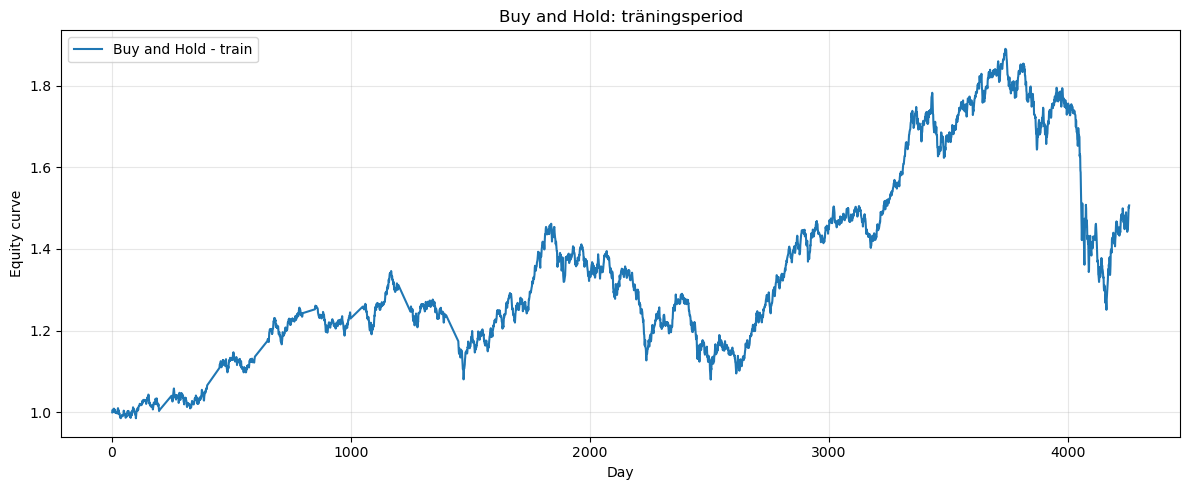

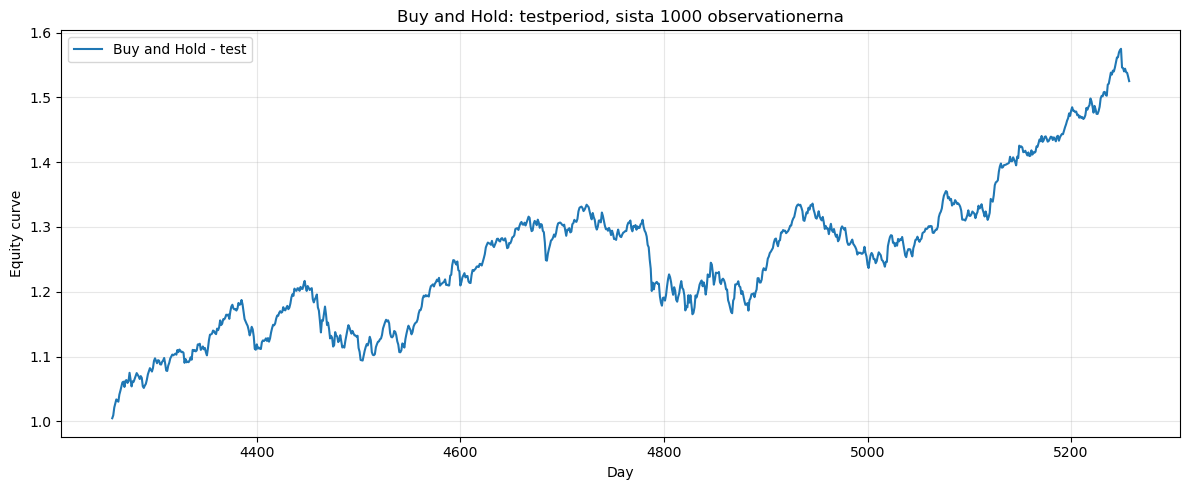

In [6]:
buy_hold_grid = {}
buy_hold_builder = lambda df, asset_columns, params: buy_and_hold_weights(df, asset_columns)

buy_hold_eval = evaluate_model_configs(
    df=df_train,
    asset_columns=asset_columns,
    day_column=DAY_COLUMN,
    model_name="Buy and Hold",
    weight_builder=buy_hold_builder,
    grid=buy_hold_grid,
    sample_label="Train"
)

buy_hold_best_params = {}
buy_hold_train_result, buy_hold_test_result = split_backtest(
    df_train=df_train,
    df_test=df_test,
    asset_columns=asset_columns,
    day_column=DAY_COLUMN,
    weight_builder=buy_hold_builder,
    params=buy_hold_best_params
)

MODEL_RUNS["Buy and Hold"] = show_model_results(
    "Buy and Hold",
    buy_hold_eval,
    buy_hold_best_params,
    buy_hold_train_result,
    buy_hold_test_result
)


## 2. MA Crossover

Första riktiga trendmodellen. Den fungerar som enkel baseline för trendföljande regler.


===== MA Crossover =====
Valda parametrar från träningsdelen:
{'short_window': 20, 'long_window': 150}

Toppresultat på träningsdelen:
       Model Sample  short_window  long_window  Observations  Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Max Drawdown
MA Crossover  Train            20          150          3901           1.640623           0.064735               0.104239      0.369908     -0.298800
MA Crossover  Train            10           50          3901           1.598634           0.063634               0.104060      0.360990     -0.217312
MA Crossover  Train            10          150          3901           1.570682           0.062891               0.104342      0.353024     -0.308329
MA Crossover  Train            10          100          3901           1.432105           0.059093               0.101724      0.324639     -0.270494
MA Crossover  Train            30          150          3901           1.449346           0.059576               0.

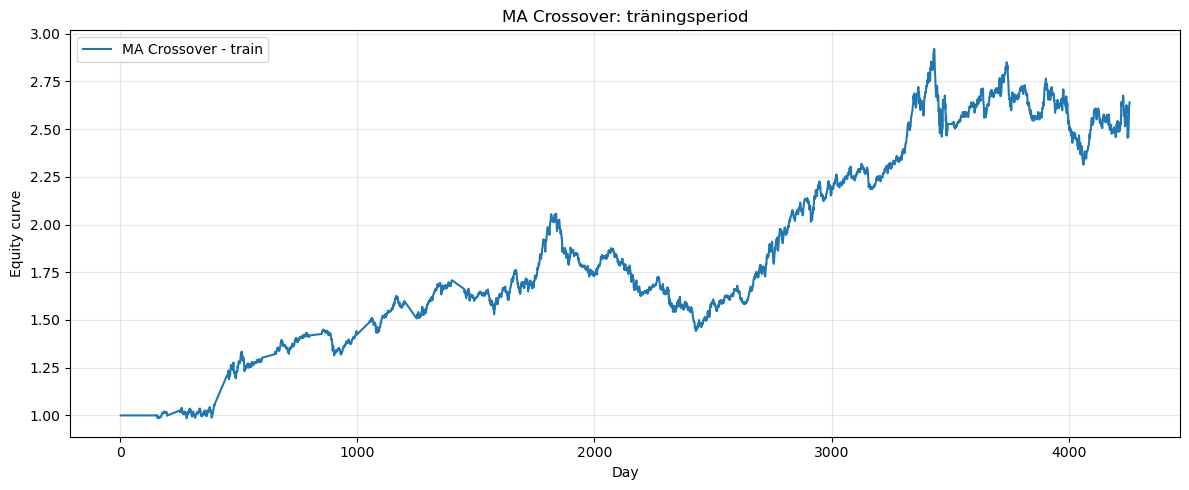

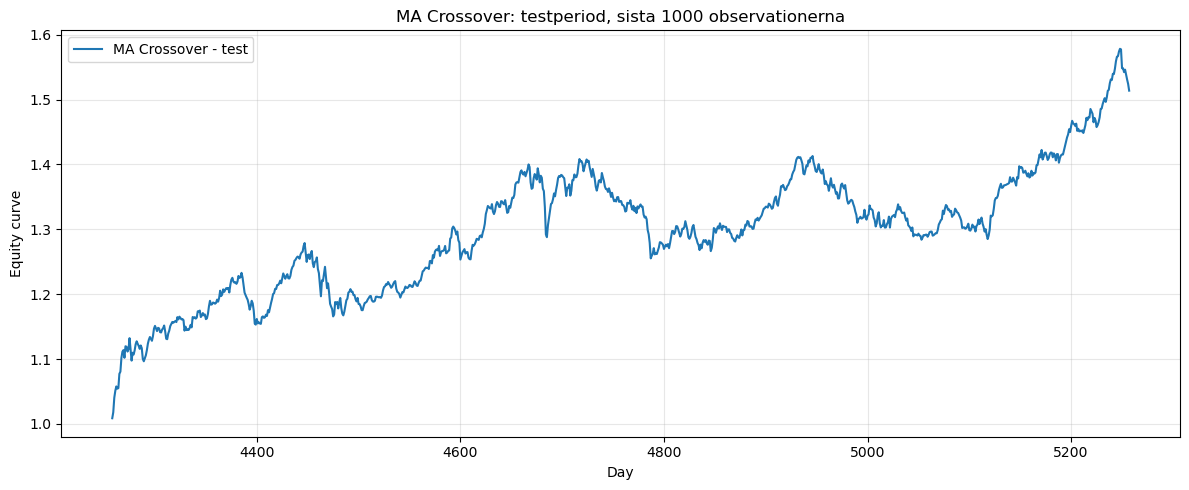

In [3]:
ma_grid = {
    "short_window": SHORT_WINDOWS,
    "long_window": LONG_WINDOWS,
}
ma_builder = lambda df, asset_columns, params: ma_crossover_weights(
    df,
    asset_columns,
    int(params["short_window"]),
    int(params["long_window"])
)

ma_eval = evaluate_model_configs(
    df=df_train,
    asset_columns=asset_columns,
    day_column=DAY_COLUMN,
    model_name="MA Crossover",
    weight_builder=ma_builder,
    grid=ma_grid,
    sample_label="Train"
)

ma_best_params = {
    "short_window": int(ma_eval.iloc[0]["short_window"]),
    "long_window": int(ma_eval.iloc[0]["long_window"]),
}

ma_train_result, ma_test_result = split_backtest(
    df_train=df_train,
    df_test=df_test,
    asset_columns=asset_columns,
    day_column=DAY_COLUMN,
    weight_builder=ma_builder,
    params=ma_best_params
)

MODEL_RUNS["MA Crossover"] = show_model_results(
    "MA Crossover",
    ma_eval,
    ma_best_params,
    ma_train_result,
    ma_test_result
)


## 3. Volatility-Scaled MA

Same idea as MA-crossover but with volatility-weighting


===== Volatility-Scaled MA =====
Valda parametrar från träningsdelen:
{'short_window': 10, 'long_window': 50, 'vol_window': 10}

Toppresultat på träningsdelen:
               Model Sample  short_window  long_window  vol_window  Observations  Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Max Drawdown
Volatility-Scaled MA  Train            10           50          10          3901           2.565105           0.085583               0.079474      0.701137     -0.122425
Volatility-Scaled MA  Train            10           50          20          3901           2.374112           0.081729               0.081189      0.644199     -0.122478
Volatility-Scaled MA  Train             5           50          10          3901           2.327034           0.080748               0.081572      0.630464     -0.127072
Volatility-Scaled MA  Train            10           50         100          3901           2.191391           0.077846               0.083553      0.585254     

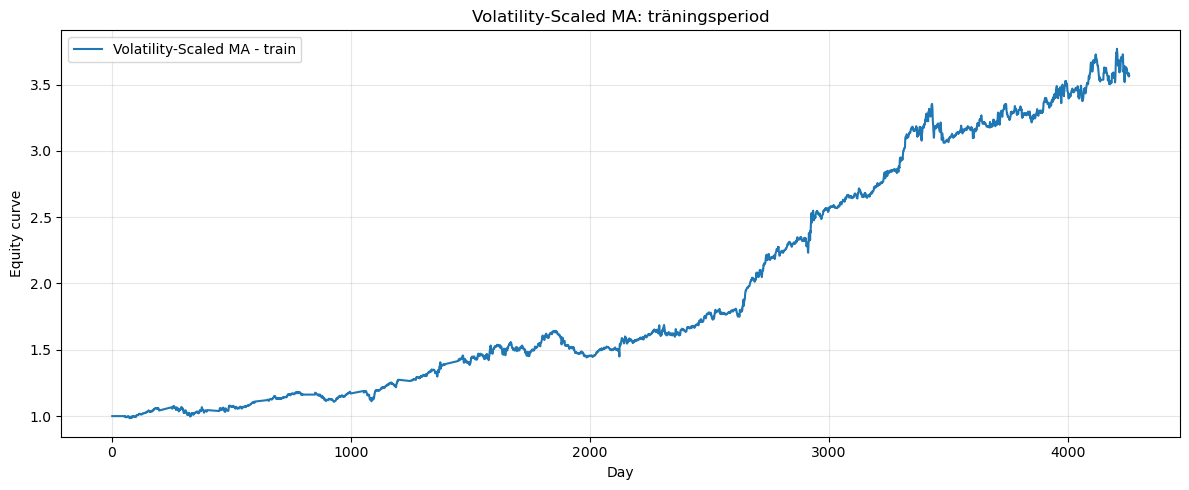

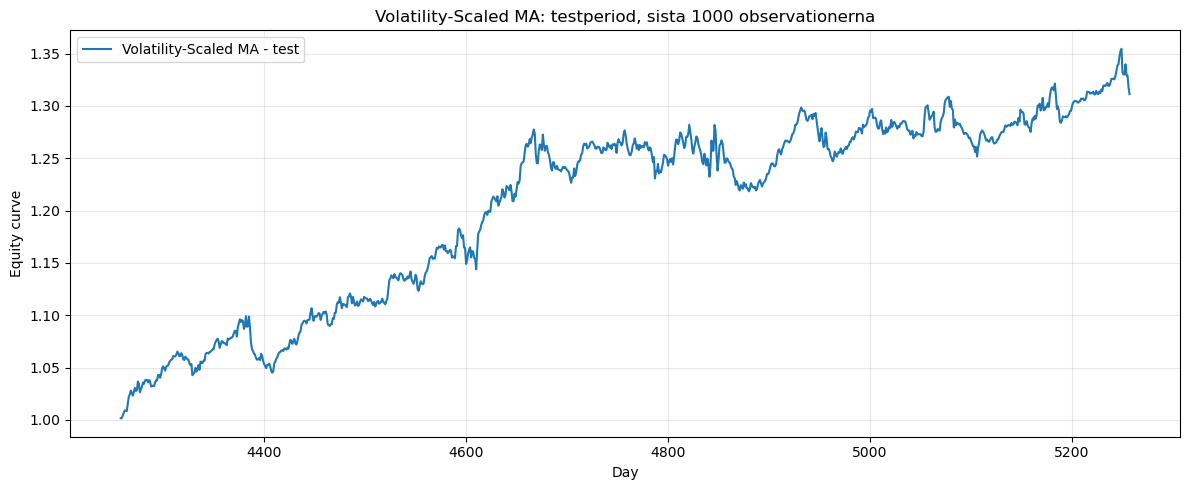

In [4]:
vol_ma_grid = {
    "short_window": SHORT_WINDOWS,
    "long_window": LONG_WINDOWS,
    "vol_window": VOL_WINDOWS,
}
vol_ma_builder = lambda df, asset_columns, params: volatility_scaled_ma_weights(
    df,
    asset_columns,
    int(params["short_window"]),
    int(params["long_window"]),
    int(params["vol_window"])
)

vol_ma_eval = evaluate_model_configs(
    df=df_train,
    asset_columns=asset_columns,
    day_column=DAY_COLUMN,
    model_name="Volatility-Scaled MA",
    weight_builder=vol_ma_builder,
    grid=vol_ma_grid,
    sample_label="Train"
)

vol_ma_best_params = {
    "short_window": int(vol_ma_eval.iloc[0]["short_window"]),
    "long_window": int(vol_ma_eval.iloc[0]["long_window"]),
    "vol_window": int(vol_ma_eval.iloc[0]["vol_window"]),
}

vol_ma_train_result, vol_ma_test_result = split_backtest(
    df_train=df_train,
    df_test=df_test,
    asset_columns=asset_columns,
    day_column=DAY_COLUMN,
    weight_builder=vol_ma_builder,
    params=vol_ma_best_params
)

MODEL_RUNS["Volatility-Scaled MA"] = show_model_results(
    "Volatility-Scaled MA",
    vol_ma_eval,
    vol_ma_best_params,
    vol_ma_train_result,
    vol_ma_test_result
)


## 4. Corr-Penalized Volatility MA

Introduces a correlation penalty in order to lower koncentration in similair assets.
WARNING, The code takes 20min to run. The result is: Corr-Penalized Volatility MA  Train  short=10  long=50  vol=10  corr=10

===== Corr-Penalized Volatility MA =====
Valda parametrar från träningsdelen:
{'short_window': 10, 'long_window': 50, 'vol_window': 10, 'corr_window': 10}

Toppresultat på träningsdelen:
                       Model Sample  short_window  long_window  vol_window  corr_window  Observations  Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Max Drawdown
Corr-Penalized Volatility MA  Train            10           50          10           10          3901           2.615642           0.086571               0.079006      0.716332     -0.122274
Corr-Penalized Volatility MA  Train            10           50          10           50          3901           2.557159           0.085427               0.079220      0.701309     -0.122429
Corr-Penalized Volatility MA  Train            10           50          10          100          3901           2.553579           0.085356               0.079131      0.701188     -0.123261
Corr-Penalized Volatility MA  Train            10

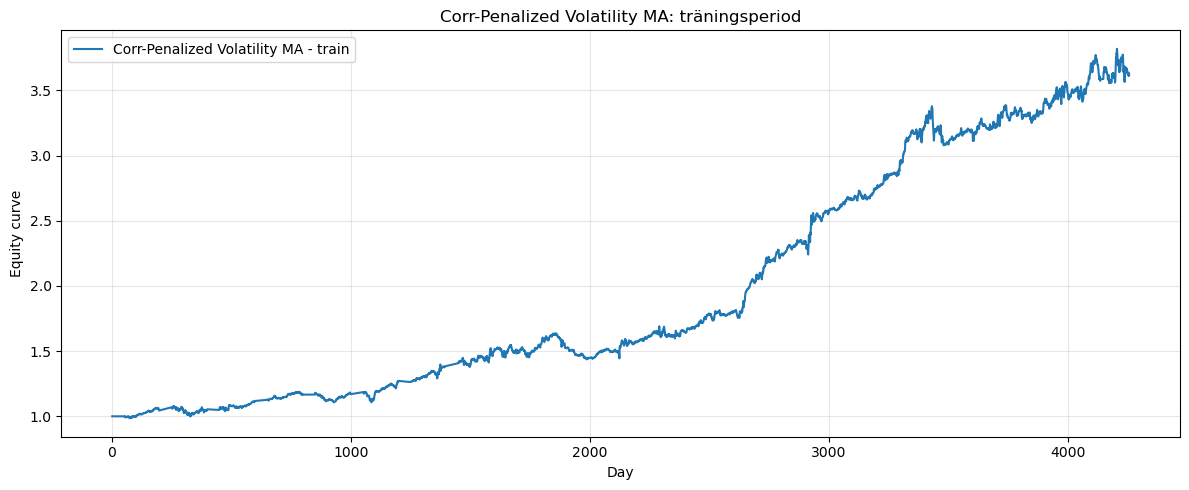

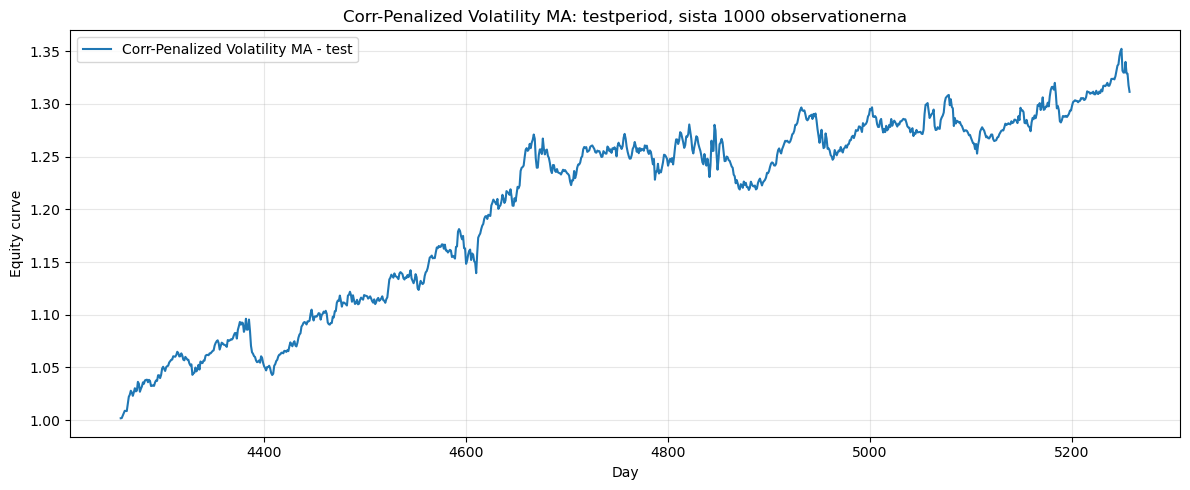

In [5]:
corr_vol_ma_grid = {
    "short_window": SHORT_WINDOWS,
    "long_window": LONG_WINDOWS,
    "vol_window": VOL_WINDOWS,
    "corr_window": CORR_WINDOWS,
}
corr_vol_ma_builder = lambda df, asset_columns, params: corr_penalized_vol_ma_weights(
    df,
    asset_columns,
    int(params["short_window"]),
    int(params["long_window"]),
    int(params["vol_window"]),
    int(params["corr_window"])
)

corr_vol_ma_eval = evaluate_model_configs(
    df=df_train,
    asset_columns=asset_columns,
    day_column=DAY_COLUMN,
    model_name="Corr-Penalized Volatility MA",
    weight_builder=corr_vol_ma_builder,
    grid=corr_vol_ma_grid,
    sample_label="Train"
)

corr_vol_ma_best_params = {
    "short_window": int(corr_vol_ma_eval.iloc[0]["short_window"]),
    "long_window": int(corr_vol_ma_eval.iloc[0]["long_window"]),
    "vol_window": int(corr_vol_ma_eval.iloc[0]["vol_window"]),
    "corr_window": int(corr_vol_ma_eval.iloc[0]["corr_window"]),
}

corr_vol_ma_train_result, corr_vol_ma_test_result = split_backtest(
    df_train=df_train,
    df_test=df_test,
    asset_columns=asset_columns,
    day_column=DAY_COLUMN,
    weight_builder=corr_vol_ma_builder,
    params=corr_vol_ma_best_params
)

MODEL_RUNS["Corr-Penalized Volatility MA"] = show_model_results(
    "Corr-Penalized Volatility MA",
    corr_vol_ma_eval,
    corr_vol_ma_best_params,
    corr_vol_ma_train_result,
    corr_vol_ma_test_result
)


## 5. Channel Breakout



===== Channel Breakout =====
Valda parametrar från träningsdelen:
{'lookback': 150}

Toppresultat på träningsdelen:
           Model Sample  lookback  Observations  Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Max Drawdown
Channel Breakout  Train       150          3901           0.146795           0.008887               0.102330     -0.152783     -0.416836
Channel Breakout  Train       100          3901           0.067540           0.004231               0.106939     -0.184921     -0.401395
Channel Breakout  Train        50          3901          -0.206950          -0.014867               0.116732     -0.324505     -0.525538
Channel Breakout  Train        20          3901          -0.553009          -0.050686               0.115433     -0.648404     -0.686089

Out-of-sample-resultat på testdelen:
           Model  lookback  Observations  Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Max Drawdown
Channel Breakout       150     

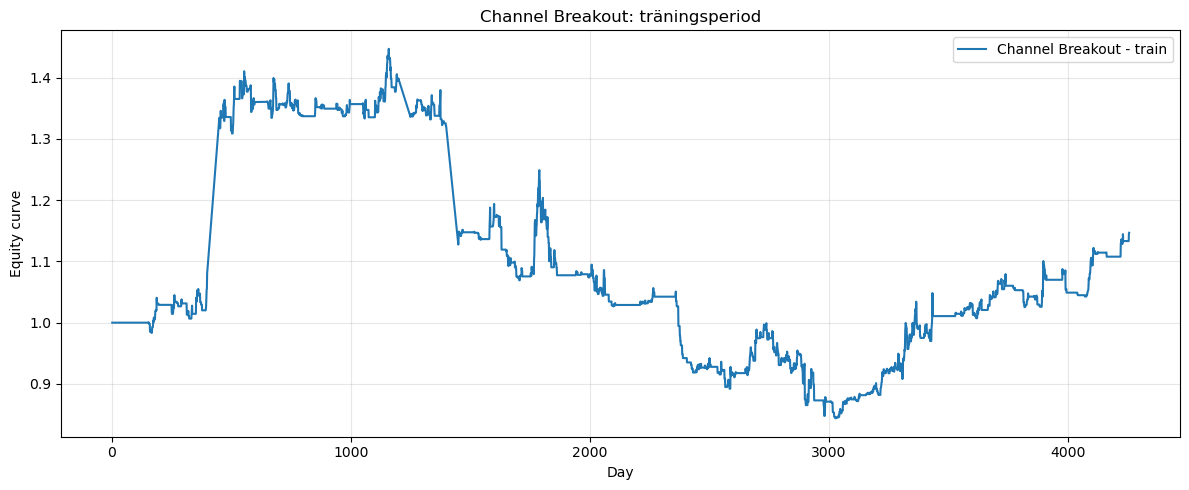

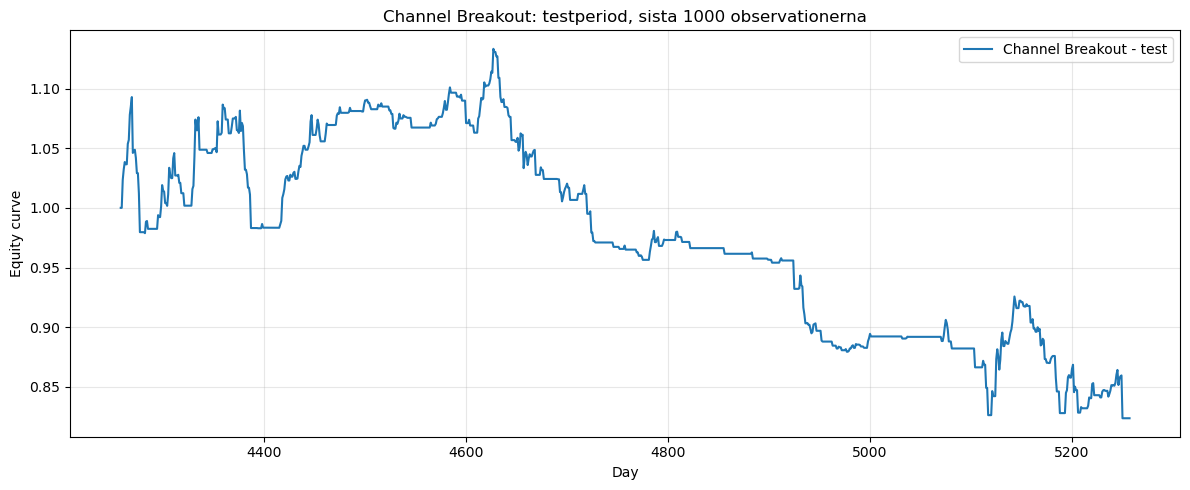

In [7]:
breakout_grid = {
    "lookback": BREAKOUT_LOOKBACKS,
}
breakout_builder = lambda df, asset_columns, params: channel_breakout_weights(
    df,
    asset_columns,
    int(params["lookback"])
)

breakout_eval = evaluate_model_configs(
    df=df_train,
    asset_columns=asset_columns,
    day_column=DAY_COLUMN,
    model_name="Channel Breakout",
    weight_builder=breakout_builder,
    grid=breakout_grid,
    sample_label="Train"
)

breakout_best_params = {
    "lookback": int(breakout_eval.iloc[0]["lookback"]),
}

breakout_train_result, breakout_test_result = split_backtest(
    df_train=df_train,
    df_test=df_test,
    asset_columns=asset_columns,
    day_column=DAY_COLUMN,
    weight_builder=breakout_builder,
    params=breakout_best_params
)

MODEL_RUNS["Channel Breakout"] = show_model_results(
    "Channel Breakout",
    breakout_eval,
    breakout_best_params,
    breakout_train_result,
    breakout_test_result
)


## 6. Basic Buy Dips


===== Basic Buy Dips =====
Valda parametrar från träningsdelen:
{'long_ma_window': 150, 'dip_lookback': 5}

Toppresultat på träningsdelen:
         Model Sample  long_ma_window  dip_lookback  Observations  Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Max Drawdown
Basic Buy Dips  Train             150             5          3901           1.688812           0.065980               0.126246      0.335143     -0.320455
Basic Buy Dips  Train             100             5          3901           1.711370           0.066556               0.129050      0.334864     -0.279744
Basic Buy Dips  Train             200             3          3901           1.619110           0.064173               0.127883      0.319254     -0.246040
Basic Buy Dips  Train             100             3          3901           1.678804           0.065723               0.146467      0.309147     -0.367991
Basic Buy Dips  Train             150             3          3901           1.333719  

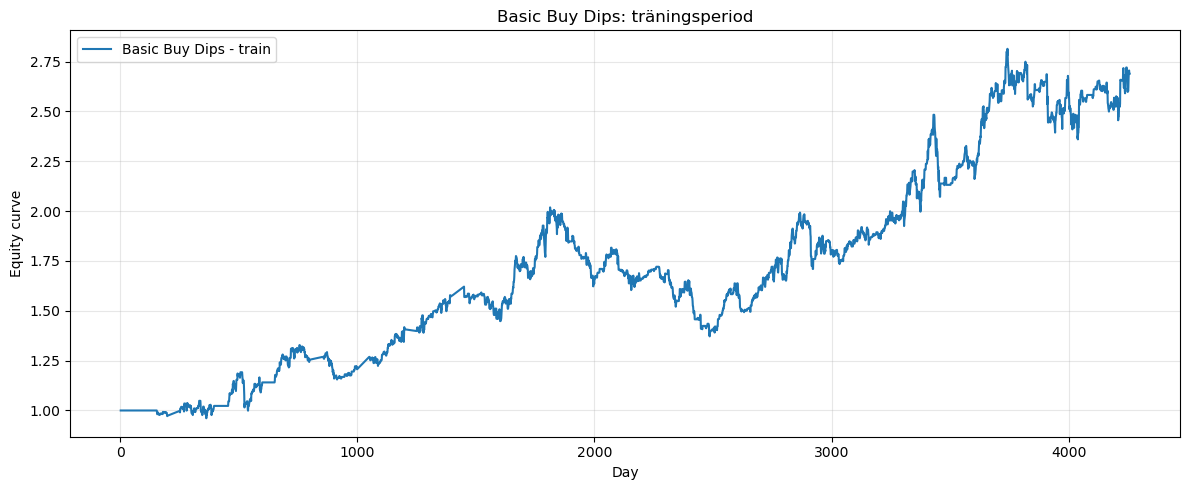

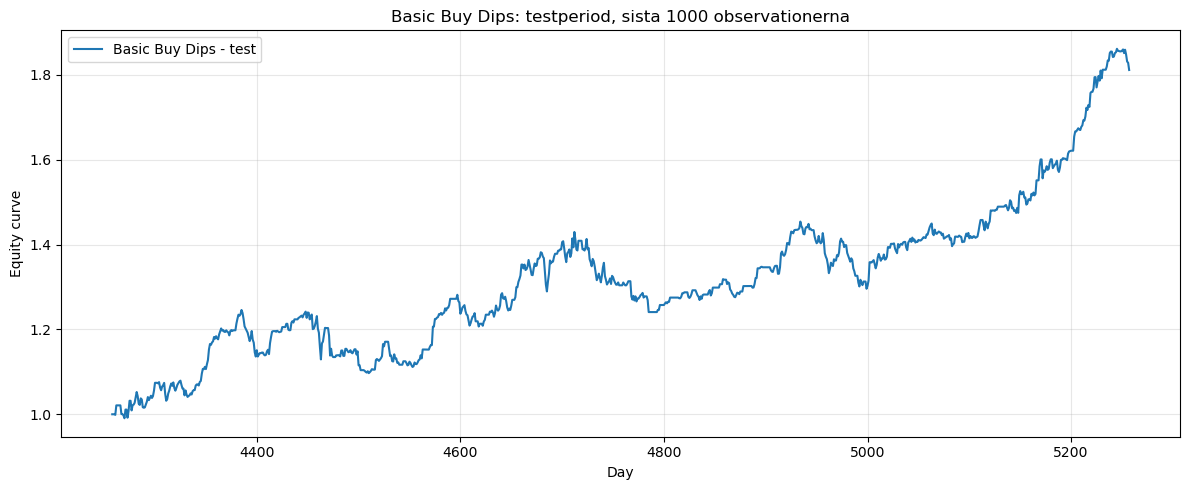

In [8]:
basic_dips_grid = {
    "long_ma_window": DIP_LONG_MA_WINDOWS,
    "dip_lookback": DIP_LOOKBACKS,
}
basic_dips_builder = lambda df, asset_columns, params: basic_buy_dips_weights(
    df,
    asset_columns,
    int(params["long_ma_window"]),
    int(params["dip_lookback"])
)

basic_dips_eval = evaluate_model_configs(
    df=df_train,
    asset_columns=asset_columns,
    day_column=DAY_COLUMN,
    model_name="Basic Buy Dips",
    weight_builder=basic_dips_builder,
    grid=basic_dips_grid,
    sample_label="Train"
)

basic_dips_best_params = {
    "long_ma_window": int(basic_dips_eval.iloc[0]["long_ma_window"]),
    "dip_lookback": int(basic_dips_eval.iloc[0]["dip_lookback"]),
}

basic_dips_train_result, basic_dips_test_result = split_backtest(
    df_train=df_train,
    df_test=df_test,
    asset_columns=asset_columns,
    day_column=DAY_COLUMN,
    weight_builder=basic_dips_builder,
    params=basic_dips_best_params
)

MODEL_RUNS["Basic Buy Dips"] = show_model_results(
    "Basic Buy Dips",
    basic_dips_eval,
    basic_dips_best_params,
    basic_dips_train_result,
    basic_dips_test_result
)


## 7. Buy Dips + Global Vol Filter

Buy Dips, anpassad utifrån 

===== Buy Dips + Global Vol Filter =====
Valda parametrar från träningsdelen:
{'long_ma_window': 100, 'dip_lookback': 3, 'global_vol_window': 50, 'vol_threshold_multiplier': 1.1}

Toppresultat på träningsdelen:
                       Model Sample  long_ma_window  dip_lookback  global_vol_window  vol_threshold_multiplier  Observations  Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Max Drawdown
Buy Dips + Global Vol Filter  Train             100             3                 50                      1.10          3901           2.035765           0.074370               0.120642      0.409934     -0.151374
Buy Dips + Global Vol Filter  Train             100             5                 20                      1.10          3901           1.842232           0.069808               0.117876      0.380710     -0.258952
Buy Dips + Global Vol Filter  Train             150             5                 20                      1.10          3901           1.532934    

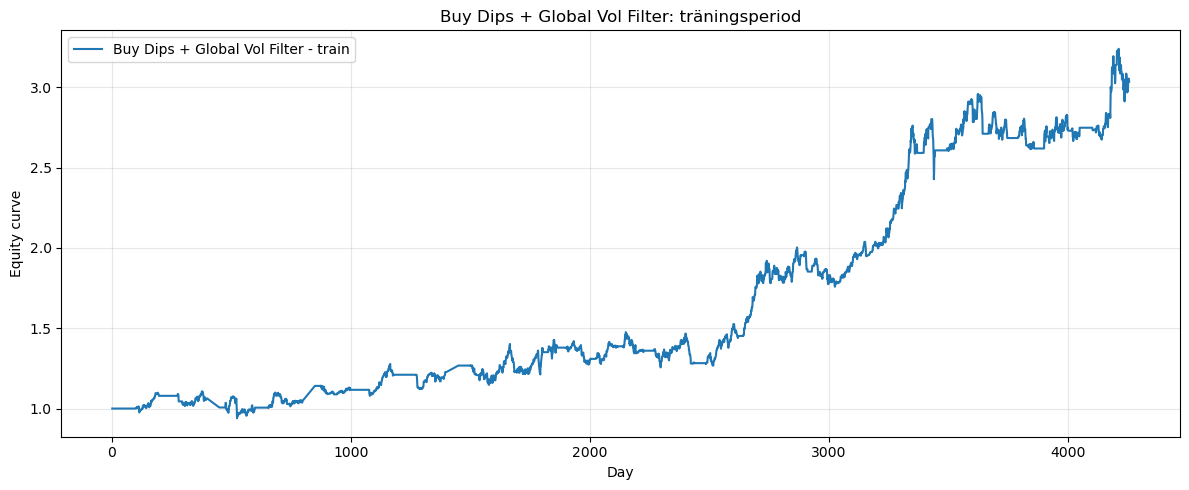

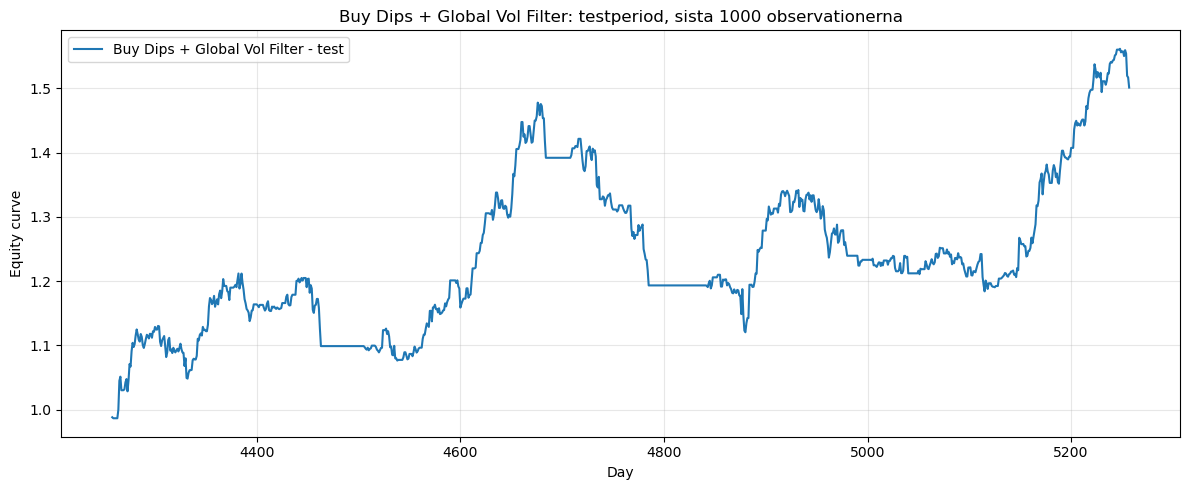

In [9]:
dips_vol_grid = {
    "long_ma_window": DIP_LONG_MA_WINDOWS,
    "dip_lookback": DIP_LOOKBACKS,
    "global_vol_window": GLOBAL_VOL_WINDOWS,
    "vol_threshold_multiplier": VOL_THRESHOLD_MULTIPLIERS,
}
dips_vol_builder = lambda df, asset_columns, params: buy_dips_global_vol_weights(
    df,
    asset_columns,
    int(params["long_ma_window"]),
    int(params["dip_lookback"]),
    int(params["global_vol_window"]),
    float(params["vol_threshold_multiplier"])
)

dips_vol_eval = evaluate_model_configs(
    df=df_train,
    asset_columns=asset_columns,
    day_column=DAY_COLUMN,
    model_name="Buy Dips + Global Vol Filter",
    weight_builder=dips_vol_builder,
    grid=dips_vol_grid,
    sample_label="Train"
)

dips_vol_best_params = {
    "long_ma_window": int(dips_vol_eval.iloc[0]["long_ma_window"]),
    "dip_lookback": int(dips_vol_eval.iloc[0]["dip_lookback"]),
    "global_vol_window": int(dips_vol_eval.iloc[0]["global_vol_window"]),
    "vol_threshold_multiplier": float(dips_vol_eval.iloc[0]["vol_threshold_multiplier"]),
}

dips_vol_train_result, dips_vol_test_result = split_backtest(
    df_train=df_train,
    df_test=df_test,
    asset_columns=asset_columns,
    day_column=DAY_COLUMN,
    weight_builder=dips_vol_builder,
    params=dips_vol_best_params
)

MODEL_RUNS["Buy Dips + Global Vol Filter"] = show_model_results(
    "Buy Dips + Global Vol Filter",
    dips_vol_eval,
    dips_vol_best_params,
    dips_vol_train_result,
    dips_vol_test_result
)


## 8. Summary



In [10]:
summary_rows = []

for model_name, run_data in MODEL_RUNS.items():
    summary_rows.append({
        "Model": model_name,
        **run_data["best_params"],
        **run_data["test_metrics"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Sharpe Ratio", ascending=False).reset_index(drop=True)
print(summary_df.to_string(index=False))


                       Model  Observations  Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Max Drawdown  short_window  long_window  vol_window  corr_window  lookback  long_ma_window  dip_lookback  global_vol_window  vol_threshold_multiplier
              Basic Buy Dips          1000           0.811154           0.161461               0.126634      1.012144     -0.132042           NaN          NaN         NaN          NaN       NaN           150.0           5.0                NaN                       NaN
                Buy and Hold          1000           0.525149           0.112230               0.089248      0.905467     -0.126743           NaN          NaN         NaN          NaN       NaN             NaN           NaN                NaN                       NaN
                MA Crossover          1000           0.513829           0.110144               0.088473      0.891400     -0.108728          20.0        150.0         NaN          NaN       NaN

## 9. Heat map of performance across time windows

                       Model  Window Length  Average Sharpe  Min Sharpe  Max Sharpe  Num Windows
              Basic Buy Dips            100        1.019627   -2.506651    4.516366          901
              Basic Buy Dips            200        0.693815   -1.132502    3.166087          801
              Basic Buy Dips            500        0.557027    0.011471    1.473868          501
              Basic Buy Dips           1000        1.012144    1.012144    1.012144            1
                Buy and Hold            100        0.924062   -3.114989    4.676269          901
                Buy and Hold            200        0.636104   -1.605837    3.651003          801
                Buy and Hold            500        0.311279   -0.283345    1.140380          501
                Buy and Hold           1000        0.905467    0.905467    0.905467            1
                MA Crossover            100        0.634415   -3.028456    4.482599          901
                MA Crossover  

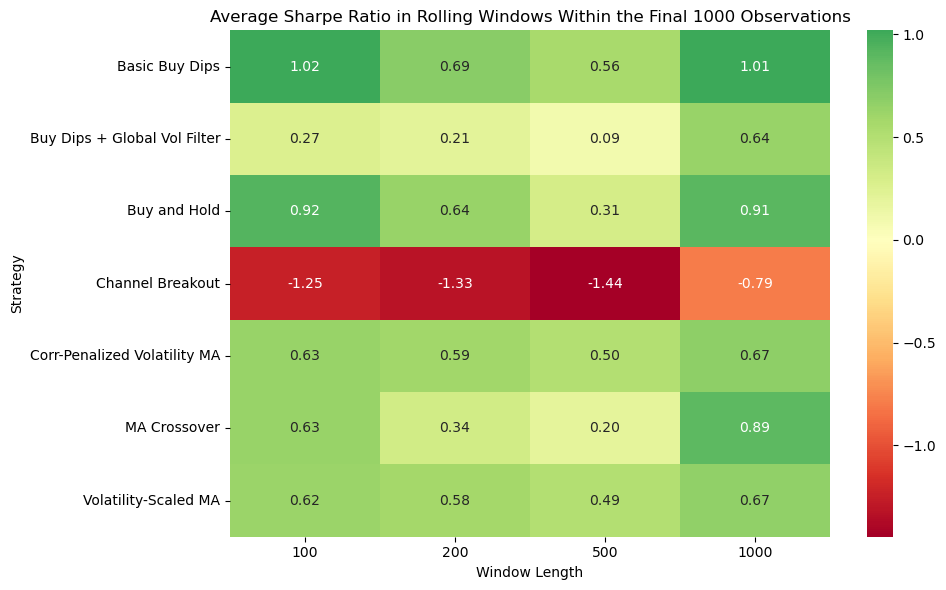

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

FILE_PATH = "/Users/maxswegmark/Desktop/project_financial_timeseries/data/spiff_data-2_interpolerad.csv"
DAY_COLUMN = "day_original"
RISK_FREE_RATE = 0.03
TRADING_DAYS = 252
TEST_WINDOW = 1000
EVAL_WINDOWS = [100, 200, 500, 1000]

MODEL_SPECS = {
    "Basic Buy Dips": {
        "type": "basic_buy_dips",
        "params": {
            "long_ma_window": 150,
            "dip_lookback": 5,
        }
    },
    "Buy and Hold": {
        "type": "buy_and_hold",
        "params": {}
    },
    "MA Crossover": {
        "type": "ma_crossover",
        "params": {
            "short_window": 20,
            "long_window": 150,
        }
    },
    "Corr-Penalized Volatility MA": {
        "type": "corr_penalized_vol_ma",
        "params": {
            "short_window": 10,
            "long_window": 50,
            "vol_window": 10,
            "corr_window": 10,
        }
    },
    "Volatility-Scaled MA": {
        "type": "volatility_scaled_ma",
        "params": {
            "short_window": 10,
            "long_window": 50,
            "vol_window": 10,
        }
    },
    "Buy Dips + Global Vol Filter": {
        "type": "buy_dips_global_vol",
        "params": {
            "long_ma_window": 100,
            "dip_lookback": 3,
            "global_vol_window": 50,
            "vol_threshold_multiplier": 1.1,
        }
    },
    "Channel Breakout": {
        "type": "channel_breakout",
        "params": {
            "lookback": 150,
        }
    },
}

def load_data(file_path, day_column):
    df = pd.read_csv(file_path).copy()
    asset_columns = [col for col in df.columns if col.endswith("_interpolated")]
    if not asset_columns:
        raise ValueError("No '*_interpolated' columns were found in the file.")
    df = df[[day_column] + asset_columns].dropna().sort_values(day_column).reset_index(drop=True)
    return df, asset_columns

def compute_returns(df, asset_columns):
    return df[asset_columns].pct_change()

def evaluate_strategy(portfolio_returns, risk_free_rate=0.03, trading_days=252):
    strategy_returns = portfolio_returns.dropna()

    if len(strategy_returns) == 0 or strategy_returns.std() == 0:
        return {
            "Observations": len(strategy_returns),
            "Sharpe Ratio": np.nan,
            "Annualized Return": np.nan,
            "Annualized Volatility": np.nan,
            "Max Drawdown": np.nan,
        }

    cumulative_return = (1 + strategy_returns).prod() - 1
    annualized_return = (1 + cumulative_return) ** (trading_days / len(strategy_returns)) - 1
    annualized_volatility = strategy_returns.std() * np.sqrt(trading_days)

    daily_rf = (1 + risk_free_rate) ** (1 / trading_days) - 1
    excess_returns = strategy_returns - daily_rf
    sharpe_ratio = (excess_returns.mean() / strategy_returns.std()) * np.sqrt(trading_days)

    wealth_index = (1 + strategy_returns).cumprod()
    running_max = wealth_index.cummax()
    drawdown = (wealth_index - running_max) / running_max
    max_drawdown = drawdown.min()

    return {
        "Observations": len(strategy_returns),
        "Sharpe Ratio": sharpe_ratio,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Max Drawdown": max_drawdown,
    }

def weights_to_result(df, asset_columns, day_column, weights):
    asset_returns = compute_returns(df, asset_columns)
    portfolio_returns = (weights * asset_returns).sum(axis=1)

    result = df[[day_column]].copy()
    result["portfolio_return"] = portfolio_returns
    result["equity_curve"] = (1 + result["portfolio_return"].fillna(0)).cumprod()
    return result

def buy_and_hold_weights(df, asset_columns, params):
    n_assets = len(asset_columns)
    return pd.DataFrame(
        np.full((len(df), n_assets), 1 / n_assets),
        index=df.index,
        columns=asset_columns
    )

def ma_crossover_weights(df, asset_columns, params):
    prices = df[asset_columns].copy()
    short_window = int(params["short_window"])
    long_window = int(params["long_window"])

    ma_short = prices.rolling(short_window).mean()
    ma_long = prices.rolling(long_window).mean()
    signals = (ma_short > ma_long).astype(float)
    positions = signals.shift(1).fillna(0)

    active_counts = positions.sum(axis=1)
    return positions.div(active_counts.replace(0, np.nan), axis=0).fillna(0)

def volatility_scaled_ma_weights(df, asset_columns, params):
    prices = df[asset_columns].copy()
    asset_returns = prices.pct_change()

    short_window = int(params["short_window"])
    long_window = int(params["long_window"])
    vol_window = int(params["vol_window"])

    ma_short = prices.rolling(short_window).mean()
    ma_long = prices.rolling(long_window).mean()
    signals = (ma_short > ma_long).astype(float)
    positions = signals.shift(1).fillna(0)

    rolling_vol = asset_returns.rolling(vol_window).std()
    inv_vol = 1 / rolling_vol.replace(0, np.nan)
    raw_weights = positions * inv_vol
    weight_sums = raw_weights.sum(axis=1)

    return raw_weights.div(weight_sums.replace(0, np.nan), axis=0).fillna(0)

def corr_penalized_vol_ma_weights(df, asset_columns, params):
    prices = df[asset_columns].copy()
    asset_returns = prices.pct_change()

    short_window = int(params["short_window"])
    long_window = int(params["long_window"])
    vol_window = int(params["vol_window"])
    corr_window = int(params["corr_window"])

    ma_short = prices.rolling(short_window).mean()
    ma_long = prices.rolling(long_window).mean()
    signals = (ma_short > ma_long).astype(float)
    positions = signals.shift(1).fillna(0)

    rolling_vol = asset_returns.rolling(vol_window).std()
    inv_vol = 1 / rolling_vol.replace(0, np.nan)

    avg_corr = pd.DataFrame(index=df.index, columns=asset_columns, dtype=float)

    for i in range(corr_window - 1, len(df)):
        window_returns = asset_returns.iloc[i - corr_window + 1:i + 1]
        corr_matrix = window_returns.corr()

        for col in asset_columns:
            other_corrs = corr_matrix.loc[col].drop(labels=col, errors="ignore").dropna()
            avg_corr.loc[df.index[i], col] = other_corrs.mean() if len(other_corrs) > 0 else np.nan

    corr_penalty = 1 / (1 + avg_corr.clip(lower=0))
    raw_weights = positions * inv_vol * corr_penalty
    weight_sums = raw_weights.sum(axis=1)

    return raw_weights.div(weight_sums.replace(0, np.nan), axis=0).fillna(0)

def channel_breakout_weights(df, asset_columns, params):
    prices = df[asset_columns].copy()
    lookback = int(params["lookback"])

    rolling_high = prices.shift(1).rolling(lookback).max()
    signals = (prices > rolling_high).astype(float)
    positions = signals.shift(1).fillna(0)

    active_counts = positions.sum(axis=1)
    return positions.div(active_counts.replace(0, np.nan), axis=0).fillna(0)

def basic_buy_dips_weights(df, asset_columns, params):
    prices = df[asset_columns].copy()
    long_ma_window = int(params["long_ma_window"])
    dip_lookback = int(params["dip_lookback"])

    long_ma = prices.rolling(long_ma_window).mean()
    trend_filter = prices > long_ma
    dip_return = prices.pct_change(dip_lookback)
    dip_signal = dip_return < 0
    signals = (trend_filter & dip_signal).astype(float)

    positions = signals.shift(1).fillna(0)
    active_counts = positions.sum(axis=1)
    return positions.div(active_counts.replace(0, np.nan), axis=0).fillna(0)

def buy_dips_global_vol_weights(df, asset_columns, params):
    prices = df[asset_columns].copy()
    asset_returns = prices.pct_change()

    long_ma_window = int(params["long_ma_window"])
    dip_lookback = int(params["dip_lookback"])
    global_vol_window = int(params["global_vol_window"])
    vol_threshold_multiplier = float(params["vol_threshold_multiplier"])

    long_ma = prices.rolling(long_ma_window).mean()
    trend_filter = prices > long_ma
    dip_return = prices.pct_change(dip_lookback)
    dip_signal = dip_return < 0

    rolling_vol = asset_returns.rolling(global_vol_window).std()
    global_vol = rolling_vol.mean(axis=1)
    global_vol_baseline = global_vol.rolling(global_vol_window).median()
    allowed_regime = global_vol <= (vol_threshold_multiplier * global_vol_baseline)
    allowed_regime_df = pd.DataFrame({col: allowed_regime for col in asset_columns}, index=df.index)

    signals = (trend_filter & dip_signal & allowed_regime_df).astype(float)
    positions = signals.shift(1).fillna(0)
    active_counts = positions.sum(axis=1)
    return positions.div(active_counts.replace(0, np.nan), axis=0).fillna(0)

STRATEGY_BUILDERS = {
    "buy_and_hold": buy_and_hold_weights,
    "ma_crossover": ma_crossover_weights,
    "volatility_scaled_ma": volatility_scaled_ma_weights,
    "corr_penalized_vol_ma": corr_penalized_vol_ma_weights,
    "channel_breakout": channel_breakout_weights,
    "basic_buy_dips": basic_buy_dips_weights,
    "buy_dips_global_vol": buy_dips_global_vol_weights,
}

def rolling_window_sharpes(result_df, window_length, risk_free_rate=0.03, trading_days=252):
    sharpes = []
    n = len(result_df)

    for start in range(0, n - window_length + 1):
        end = start + window_length
        window_returns = result_df["portfolio_return"].iloc[start:end]
        metrics = evaluate_strategy(window_returns, risk_free_rate, trading_days)
        sharpes.append(metrics["Sharpe Ratio"])

    return sharpes

df, asset_columns = load_data(FILE_PATH, DAY_COLUMN)

if len(df) < TEST_WINDOW:
    raise ValueError(f"The dataset must contain at least {TEST_WINDOW} rows.")

all_rows = []

for model_name, spec in MODEL_SPECS.items():
    strategy_type = spec["type"]
    params = spec["params"]
    weight_builder = STRATEGY_BUILDERS[strategy_type]

    # Build signals on the full dataset so each model gets proper warm-up history
    full_weights = weight_builder(df, asset_columns, params)
    full_result = weights_to_result(df, asset_columns, DAY_COLUMN, full_weights)

    # Evaluate only on the final test window
    result_last_1000 = full_result.iloc[-TEST_WINDOW:].reset_index(drop=True)

    for window_length in EVAL_WINDOWS:
        sharpes = rolling_window_sharpes(
            result_df=result_last_1000,
            window_length=window_length,
            risk_free_rate=RISK_FREE_RATE,
            trading_days=TRADING_DAYS
        )

        all_rows.append({
            "Model": model_name,
            "Window Length": window_length,
            "Average Sharpe": np.nanmean(sharpes) if len(sharpes) > 0 else np.nan,
            "Min Sharpe": np.nanmin(sharpes) if len(sharpes) > 0 else np.nan,
            "Max Sharpe": np.nanmax(sharpes) if len(sharpes) > 0 else np.nan,
            "Num Windows": len(sharpes),
        })

results_df = pd.DataFrame(all_rows)
print(results_df.to_string(index=False))

pivot_df = results_df.pivot(index="Model", columns="Window Length", values="Average Sharpe")

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, cmap="RdYlGn", center=0, fmt=".2f")
plt.title("Average Sharpe Ratio in Rolling Windows Within the Final 1000 Observations")
plt.xlabel("Window Length")
plt.ylabel("Strategy")
plt.tight_layout()
plt.show()
